# Notebook 45 — Domain-Invariant Feature Discovery

**Project:** AI VPN Firewall — Thesis Supporting Analysis
**Date:** 2026-04-04
**Author:** Scott I.
**Relation:** Direct follow-up to **Notebook 44** (*Class-Conditional Structural Audit & Rate-Feature Sanity*)

---

## Purpose

Notebook 44 demonstrated:

| Finding | Detail |
|---------|--------|
| 16 / 21 features reverse VPN-vs-nonVPN direction across datasets | Semantic inversion |
| Capture-safe domain AUC ≈ 0.998 | Near-perfect fingerprinting |
| Rate features are neutral | Neither help nor harm transfer |
| No implementation leakage | All computations verified consistent |
| Transfer failure cause | Feature-meaning semantic inversion across capture environments |

**This notebook now asks:** Can any *subset* of the 21 frozen features remain domain-invariant
enough to support cross-dataset VPN detection?

### Strategy: Stability-Based Feature Selection

Instead of alignment or recalibration, we attempt *principled feature-stability filtering*:
rank features by cross-dataset stability, select the most stable subset, and evaluate whether
LODO transfer improves.

### Design principles
- All outputs saved to `artifacts/domain_invariant_feature_discovery/` — no prior artifacts overwritten.
- All conclusions are conservative and publication-safe.
- Negative results are documented honestly.

---\n## Section 0 — Environment Setup

In [1]:
import sys, os, json, warnings, gc, time
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance, mannwhitneyu, spearmanr
from sklearn.preprocessing import LabelEncoder, RobustScaler, StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
import xgboost as xgb

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", font_scale=1.15)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CLEAN_DIR = PROJECT_ROOT / "artifacts" / "clean_pipeline"
NB44_DIR  = PROJECT_ROOT / "artifacts" / "thesis_class_conditional_audit_notebook"
OUT_DIR   = PROJECT_ROOT / "artifacts" / "domain_invariant_feature_discovery"
OUT_DIR.mkdir(parents=True, exist_ok=True)

EPS = 1e-9

print(f"Project root : {PROJECT_ROOT}")
print(f"Output dir   : {OUT_DIR}")

Project root : C:\Users\scoti\PycharmProjects\ai-vpn-firewall
Output dir   : C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\domain_invariant_feature_discovery


In [2]:
# ── Helpers ─────────────────────────────────────────────────────────────
def save_fig(fig, name, dpi=200):
    path = OUT_DIR / name
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"  Saved: {path}")
    plt.show()
    plt.close(fig)

def save_csv(df, name):
    path = OUT_DIR / name
    df.to_csv(path, index=True)
    print(f"  Saved: {path}")

def save_json(obj, name):
    path = OUT_DIR / name
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=str)
    print(f"  Saved: {path}")

In [3]:
# ── Load data ───────────────────────────────────────────────────────────
df_all = pd.read_parquet(CLEAN_DIR / "features.parquet")
print(f"Loaded {len(df_all):,} flows × {df_all.shape[1]} columns")

sys.path.insert(0, str(PROJECT_ROOT))
from src.clean_pipeline.feature_families import get_family

FROZEN_FEATURES = list(get_family("safe_core_plus_temporal"))  # 21 features
DATASETS = sorted(df_all["dataset"].unique())
print(f"Frozen features: {len(FROZEN_FEATURES)}")
print(f"Datasets: {DATASETS}")
print(f"Label distribution:\n{df_all['label'].value_counts().to_string()}")

Loaded 72,612 flows × 32 columns
Frozen features: 21
Datasets: ['iscx', 'usbvpn', 'vnat']
Label distribution:
label
0    60839
1    11773


---
## Section 1 — Feature Stability Score Across Datasets

For each of the 21 frozen features, we compute multiple stability metrics:

1. **Sign consistency**: Does the VPN-vs-nonVPN direction agree across all 3 datasets?
2. **SMD variance**: Variance of standardized mean difference across datasets (low = stable)
3. **Single-feature AUC variance**: Variance of per-dataset VPN-vs-nonVPN AUC (low = stable)
4. **Mean JSD across dataset pairs**: Jensen-Shannon divergence averaged over 3 pairs (low = stable)
5. **Domain-classifier single-feature AUC**: Can this feature alone identify the dataset? (low = stable)

**Composite stability score:**

$$\\text{stability} = \\frac{1}{4}\\left(1 - \\text{sign\\_var} + 1 - \\text{norm\\_smd\\_var} + 1 - \\text{norm\\_auc\\_var} + 1 - \\text{domain\\_auc}\\right)$$

Higher score = more domain-invariant.

In [4]:
# ── 1.1 Per-feature, per-dataset effect metrics ─────────────────────────
effect_rows = []
for ds in DATASETS:
    sub = df_all[df_all["dataset"] == ds]
    vpn = sub[sub["label"] == 1]
    nonvpn = sub[sub["label"] == 0]
    for feat in FROZEN_FEATURES:
        v = vpn[feat].dropna().values
        nv = nonvpn[feat].dropna().values
        # Standardized mean difference
        pooled_std = np.sqrt((np.var(v)*len(v) + np.var(nv)*len(nv)) / max(len(v)+len(nv), 1))
        smd = (np.mean(v) - np.mean(nv)) / max(pooled_std, EPS)
        # Single-feature AUC (VPN vs nonVPN)
        if len(v) > 0 and len(nv) > 0:
            y_true = np.concatenate([np.ones(len(v)), np.zeros(len(nv))])
            scores = np.concatenate([v, nv])
            try:
                auc = roc_auc_score(y_true, scores)
            except:
                auc = 0.5
        else:
            auc = 0.5
        effect_rows.append({
            "dataset": ds, "feature": feat,
            "smd": smd, "smd_sign": np.sign(smd),
            "vpn_vs_nonvpn_auc": auc,
        })
effect_df = pd.DataFrame(effect_rows)
print(f"Effect table: {effect_df.shape}")

Effect table: (63, 5)


In [5]:
# ── 1.2 Per-feature JSD across dataset pairs ────────────────────────────
def feature_jsd(df, feat, n_bins=100):
    '''Mean JSD for a feature across all dataset pairs.'''
    datasets = sorted(df["dataset"].unique())
    jsds = []
    for ds_a, ds_b in combinations(datasets, 2):
        va = df.loc[df["dataset"] == ds_a, feat].dropna().values
        vb = df.loc[df["dataset"] == ds_b, feat].dropna().values
        if len(va) < 10 or len(vb) < 10:
            continue
        lo, hi = min(va.min(), vb.min()), max(va.max(), vb.max())
        if hi - lo < 1e-12:
            jsds.append(0.0)
            continue
        bins = np.linspace(lo, hi, n_bins + 1)
        ha, _ = np.histogram(va, bins=bins, density=True)
        hb, _ = np.histogram(vb, bins=bins, density=True)
        ha = ha + 1e-12; hb = hb + 1e-12
        ha /= ha.sum(); hb /= hb.sum()
        jsds.append(float(jensenshannon(ha, hb)))
    return np.mean(jsds) if jsds else np.nan

jsd_rows = []
for feat in FROZEN_FEATURES:
    jsd_rows.append({"feature": feat, "mean_jsd": feature_jsd(df_all, feat)})
jsd_df = pd.DataFrame(jsd_rows)
print("JSD computed for all features")

JSD computed for all features


In [6]:
# ── 1.3 Domain-classifier single-feature AUC ───────────────────────────
def single_feature_domain_auc(df, feat):
    '''Capture-grouped domain classification AUC using a single feature.'''
    le = LabelEncoder()
    X = df[[feat]].values
    y = le.fit_transform(df["dataset"].values)
    groups = df["capture_id"].values
    n_classes = len(le.classes_)
    gkf = GroupKFold(n_splits=min(5, len(np.unique(groups))))
    aucs = []
    for tr, te in gkf.split(X, y, groups):
        clf = xgb.XGBClassifier(n_estimators=100, max_depth=3, verbosity=0,
                                use_label_encoder=False, eval_metric="mlogloss",
                                n_jobs=-1, random_state=42)
        clf.fit(X[tr], y[tr])
        prob = clf.predict_proba(X[te])
        try:
            if n_classes == 2:
                auc = roc_auc_score(y[te], prob[:, 1])
            else:
                auc = roc_auc_score(y[te], prob, multi_class="ovr", average="macro")
        except:
            auc = np.nan
        aucs.append(auc)
    return float(np.nanmean(aucs))

domain_auc_rows = []
for feat in FROZEN_FEATURES:
    da = single_feature_domain_auc(df_all, feat)
    domain_auc_rows.append({"feature": feat, "domain_auc_single": da})
    print(f"  {feat:25s} domain AUC = {da:.4f}")
domain_auc_df = pd.DataFrame(domain_auc_rows)

  total_packets             domain AUC = 0.7841
  total_bytes               domain AUC = 0.8490
  mean_pkt_len              domain AUC = 0.8558
  std_pkt_len               domain AUC = 0.8535
  median_pkt_len            domain AUC = 0.8614
  p25_pkt_len               domain AUC = 0.8328
  p75_pkt_len               domain AUC = 0.8969
  iat_mean                  domain AUC = 0.7833
  iat_std                   domain AUC = 0.8156
  iat_median                domain AUC = 0.7502
  flow_duration             domain AUC = 0.8078
  packet_rate               domain AUC = 0.7940
  byte_rate                 domain AUC = 0.7865
  max_pkt_len               domain AUC = 0.9370
  min_pkt_len               domain AUC = 0.8907
  iat_cv                    domain AUC = 0.6889
  iat_p25                   domain AUC = 0.7960
  iat_p75                   domain AUC = 0.7818
  iat_iqr                   domain AUC = 0.7830
  pkt_len_cv                domain AUC = 0.7108
  pkt_len_iqr               domain AUC =

In [7]:
# ── 1.4 Build composite stability table ─────────────────────────────────
stab_rows = []
for feat in FROZEN_FEATURES:
    feat_effect = effect_df[effect_df["feature"] == feat]

    # Sign consistency: 1 if all same sign, 0 otherwise
    signs = feat_effect["smd_sign"].values
    sign_consistent = 1.0 if len(set(signs)) == 1 else 0.0

    # SMD variance across datasets (lower = more stable)
    smd_var = float(feat_effect["smd"].var())

    # Single-feature AUC variance across datasets (lower = more stable)
    auc_var = float(feat_effect["vpn_vs_nonvpn_auc"].var())

    # Mean JSD
    mean_jsd = float(jsd_df.loc[jsd_df["feature"] == feat, "mean_jsd"].values[0])

    # Domain AUC (single feature)
    dom_auc = float(domain_auc_df.loc[domain_auc_df["feature"] == feat, "domain_auc_single"].values[0])

    # Mean SMD magnitude (for reference)
    mean_abs_smd = float(feat_effect["smd"].abs().mean())

    # Mean VPN-vs-nonVPN AUC (predictive power reference)
    mean_vpn_auc = float(feat_effect["vpn_vs_nonvpn_auc"].mean())

    stab_rows.append({
        "feature": feat,
        "sign_consistent": sign_consistent,
        "smd_variance": smd_var,
        "auc_variance": auc_var,
        "mean_jsd": mean_jsd,
        "domain_auc_single": dom_auc,
        "mean_abs_smd": mean_abs_smd,
        "mean_vpn_auc": mean_vpn_auc,
    })

stab_df = pd.DataFrame(stab_rows)

# Normalise components to [0, 1] for composite score
for col in ["smd_variance", "auc_variance", "mean_jsd"]:
    mn, mx = stab_df[col].min(), stab_df[col].max()
    stab_df[f"{col}_norm"] = (stab_df[col] - mn) / max(mx - mn, EPS)

# Composite stability score (higher = more stable / more domain-invariant)
stab_df["stability_score"] = (
    stab_df["sign_consistent"] * 0.30
    + (1 - stab_df["smd_variance_norm"]) * 0.20
    + (1 - stab_df["auc_variance_norm"]) * 0.20
    + (1 - stab_df["mean_jsd"]) * 0.15   # JSD already in [0,~0.8]
    + (1 - stab_df["domain_auc_single"]) * 0.15
)

stab_df = stab_df.sort_values("stability_score", ascending=False).reset_index(drop=True)
display(stab_df[["feature", "sign_consistent", "smd_variance", "auc_variance",
                 "mean_jsd", "domain_auc_single", "mean_abs_smd", "mean_vpn_auc",
                 "stability_score"]].round(4))

save_csv(stab_df, "feature_stability_table.csv")
save_csv(stab_df, "feature_stability_ranking.csv")   # alias for final deliverable

,feature,sign_consistent,smd_variance,auc_variance,mean_jsd,domain_auc_single,mean_abs_smd,mean_vpn_auc,stability_score
0,flow_duration,1.0,0.0234,0.0076,0.2942,0.8078,0.1396,0.4806,0.8342
1,iat_mean,1.0,0.0221,0.0869,0.2932,0.7833,0.1435,0.4176,0.7402
2,iat_p75,1.0,0.0207,0.0997,0.2738,0.7818,0.1546,0.4241,0.7277
3,total_bytes,1.0,0.5528,0.0800,0.2836,0.8490,0.4939,0.5070,0.6376
4,total_packets,1.0,0.5091,0.0790,0.4650,0.7841,0.7864,0.5241,0.6298
5,iat_std,0.0,0.0380,0.0421,0.2900,0.8156,0.1258,0.4168,0.4881
6,pkt_len_iqr,0.0,0.0883,0.0545,0.3755,0.8040,0.2320,0.4655,0.4519
7,iat_iqr,0.0,0.0312,0.0976,0.2719,0.7830,0.1386,0.4314,0.4284
8,max_pkt_len,0.0,0.1514,0.0541,0.4251,0.9370,0.2905,0.4325,0.4130
9,iat_cv,0.0,0.3002,0.0717,0.3487,0.6889,0.4044,0.4608,0.4110


  Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\domain_invariant_feature_discovery\feature_stability_table.csv
  Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\domain_invariant_feature_discovery\feature_stability_ranking.csv


In [8]:
# ── 1.5 Stability ranking visualisation ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#2ecc71" if s else "#e74c3c" for s in stab_df["sign_consistent"]]
ax.barh(stab_df["feature"], stab_df["stability_score"], color=colors, edgecolor="white")
ax.set_xlabel("Stability Score (higher = more domain-invariant)")
ax.set_title("Feature Stability Ranking\n(green = sign-consistent, red = sign-reversing)")
ax.invert_yaxis()
fig.tight_layout()
save_fig(fig, "feature_stability_ranking.png")

  Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\domain_invariant_feature_discovery\feature_stability_ranking.png


### Interpretation

Features are ranked from most to least domain-invariant. The composite score weighs:
- Sign consistency (30%): Does VPN→high consistently across datasets?
- SMD variance (20%): How variable is the effect size?
- AUC variance (20%): How variable is per-dataset predictive power?
- Mean JSD (15%): How different are the marginal distributions?
- Domain AUC (15%): Can this feature alone identify which dataset a flow comes from?

**Key insight:** Only sign-consistent features can possibly support cross-dataset transfer. Sign-reversing features actively harm transfer regardless of their predictive power within a single dataset.

---
## Section 2 — Stable Feature Subset Selection

We construct feature subsets of increasing size using the stability ranking, and evaluate each:

- **LODO AUC** (leave-one-dataset-out — the gold standard for cross-dataset transfer)
- **Pooled AUC** (all data, standard train/test — for reference)
- **Domain classifier AUC** (can the subset identify dataset identity?)

Subsets: top-3, top-5, top-7, top-10 by stability score.
Baseline: full_no_dir (all 21 features).

In [9]:
# ── Evaluation helpers ──────────────────────────────────────────────────
def lodo_eval(df, feat_cols, held_out_ds, seed=42):
    '''LODO: train on 2 datasets, test on held-out.'''
    train = df[df["dataset"] != held_out_ds]
    test  = df[df["dataset"] == held_out_ds]
    if len(test) < 10 or test["label"].nunique() < 2:
        return {"held_out": held_out_ds, "auc": np.nan, "recall": np.nan, "fpr": np.nan}
    X_tr, y_tr = train[feat_cols].values, train["label"].values
    X_te, y_te = test[feat_cols].values,  test["label"].values
    clf = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                            use_label_encoder=False, eval_metric="logloss",
                            verbosity=0, n_jobs=-1, random_state=seed)
    clf.fit(X_tr, y_tr)
    y_prob = clf.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    auc = roc_auc_score(y_te, y_prob) if len(np.unique(y_te)) > 1 else np.nan
    tp = ((y_pred == 1) & (y_te == 1)).sum()
    fn = ((y_pred == 0) & (y_te == 1)).sum()
    fp = ((y_pred == 1) & (y_te == 0)).sum()
    tn = ((y_pred == 0) & (y_te == 0)).sum()
    return {"held_out": held_out_ds, "auc": float(auc),
            "recall": float(tp/max(tp+fn,1)), "fpr": float(fp/max(fp+tn,1))}

def run_lodo_suite(df, feat_cols, suite_name):
    rows = []
    for ds in DATASETS:
        r = lodo_eval(df, feat_cols, ds)
        r["suite"] = suite_name
        r["n_features"] = len(feat_cols)
        rows.append(r)
    return pd.DataFrame(rows)

def pooled_auc(df, feat_cols, seed=42):
    '''Simple pooled train/test AUC using split column.'''
    train = df[df["split"] == "train"]
    test  = df[df["split"] == "test"]
    if len(test) < 10 or test["label"].nunique() < 2:
        return np.nan
    clf = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                            use_label_encoder=False, eval_metric="logloss",
                            verbosity=0, n_jobs=-1, random_state=seed)
    clf.fit(train[feat_cols].values, train["label"].values)
    prob = clf.predict_proba(test[feat_cols].values)[:, 1]
    return float(roc_auc_score(test["label"].values, prob))

def domain_detector_auc(df, feat_cols):
    '''Capture-grouped domain classification AUC.'''
    le = LabelEncoder()
    X = df[feat_cols].values
    y = le.fit_transform(df["dataset"].values)
    groups = df["capture_id"].values
    gkf = GroupKFold(n_splits=min(5, len(np.unique(groups))))
    aucs = []
    for tr, te in gkf.split(X, y, groups):
        clf = xgb.XGBClassifier(n_estimators=100, max_depth=3, verbosity=0,
                                use_label_encoder=False, eval_metric="mlogloss",
                                n_jobs=-1, random_state=42)
        clf.fit(X[tr], y[tr])
        prob = clf.predict_proba(X[te])
        try:
            auc = roc_auc_score(y[te], prob, multi_class="ovr", average="macro")
        except:
            auc = np.nan
        aucs.append(auc)
    return float(np.nanmean(aucs))

In [10]:
# ── 2.1 Build subsets and evaluate ──────────────────────────────────────
stability_ranked = stab_df["feature"].tolist()
subset_sizes = [3, 5, 7, 10]
results = []

# Baseline: full 21
print("Evaluating baseline (full_no_dir, 21 features)...")
lodo_base = run_lodo_suite(df_all, FROZEN_FEATURES, "full_no_dir_21")
pool_base = pooled_auc(df_all, FROZEN_FEATURES)
dd_base   = domain_detector_auc(df_all, FROZEN_FEATURES)
results.append({
    "suite": "full_no_dir_21", "n_features": 21,
    "features": FROZEN_FEATURES,
    "lodo_min_auc": lodo_base["auc"].min(),
    "lodo_mean_auc": lodo_base["auc"].mean(),
    "lodo_iscx": lodo_base.loc[lodo_base["held_out"]=="iscx","auc"].values[0] if "iscx" in lodo_base["held_out"].values else np.nan,
    "lodo_usbvpn": lodo_base.loc[lodo_base["held_out"]=="usbvpn","auc"].values[0] if "usbvpn" in lodo_base["held_out"].values else np.nan,
    "lodo_vnat": lodo_base.loc[lodo_base["held_out"]=="vnat","auc"].values[0] if "vnat" in lodo_base["held_out"].values else np.nan,
    "pooled_auc": pool_base,
    "domain_auc": dd_base,
})
print(f"  Baseline: LODO min={lodo_base['auc'].min():.4f}, pooled={pool_base:.4f}, domain={dd_base:.4f}")

for k in subset_sizes:
    feat_subset = stability_ranked[:k]
    suite_name = f"stability_top{k}"
    print(f"\nEvaluating {suite_name} ({feat_subset})...")
    lodo_k = run_lodo_suite(df_all, feat_subset, suite_name)
    pool_k = pooled_auc(df_all, feat_subset)
    dd_k   = domain_detector_auc(df_all, feat_subset)
    results.append({
        "suite": suite_name, "n_features": k,
        "features": feat_subset,
        "lodo_min_auc": lodo_k["auc"].min(),
        "lodo_mean_auc": lodo_k["auc"].mean(),
        "lodo_iscx": lodo_k.loc[lodo_k["held_out"]=="iscx","auc"].values[0] if "iscx" in lodo_k["held_out"].values else np.nan,
        "lodo_usbvpn": lodo_k.loc[lodo_k["held_out"]=="usbvpn","auc"].values[0] if "usbvpn" in lodo_k["held_out"].values else np.nan,
        "lodo_vnat": lodo_k.loc[lodo_k["held_out"]=="vnat","auc"].values[0] if "vnat" in lodo_k["held_out"].values else np.nan,
        "pooled_auc": pool_k,
        "domain_auc": dd_k,
    })
    print(f"  {suite_name}: LODO min={lodo_k['auc'].min():.4f}, pooled={pool_k:.4f}, domain={dd_k:.4f}")

results_df = pd.DataFrame(results)
display(results_df[["suite","n_features","lodo_min_auc","lodo_mean_auc","pooled_auc","domain_auc"]].round(4))
save_csv(results_df.drop(columns=["features"]), "stability_subset_evaluation.csv")

Evaluating baseline (full_no_dir, 21 features)...
  Baseline: LODO min=0.4964, pooled=0.9944, domain=0.9971

Evaluating stability_top3 (['flow_duration', 'iat_mean', 'iat_p75'])...
  stability_top3: LODO min=0.2806, pooled=0.9237, domain=0.9095

Evaluating stability_top5 (['flow_duration', 'iat_mean', 'iat_p75', 'total_bytes', 'total_packets'])...
  stability_top5: LODO min=0.3749, pooled=0.9484, domain=0.9546

Evaluating stability_top7 (['flow_duration', 'iat_mean', 'iat_p75', 'total_bytes', 'total_packets', 'iat_std', 'pkt_len_iqr'])...
  stability_top7: LODO min=0.4531, pooled=0.9600, domain=0.9767

Evaluating stability_top10 (['flow_duration', 'iat_mean', 'iat_p75', 'total_bytes', 'total_packets', 'iat_std', 'pkt_len_iqr', 'iat_iqr', 'max_pkt_len', 'iat_cv'])...
  stability_top10: LODO min=0.5210, pooled=0.9695, domain=0.9875


,suite,n_features,lodo_min_auc,lodo_mean_auc,pooled_auc,domain_auc
0,full_no_dir_21,21,0.4964,0.5498,0.9944,0.9971
1,stability_top3,3,0.2806,0.3917,0.9237,0.9095
2,stability_top5,5,0.3749,0.4412,0.9484,0.9546
3,stability_top7,7,0.4531,0.4873,0.9600,0.9767
4,stability_top10,10,0.5210,0.6468,0.9695,0.9875


  Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\domain_invariant_feature_discovery\stability_subset_evaluation.csv


### Section 2 — Interpretation

Compare LODO min AUC across subsets. If stability-ranked subsets achieve materially higher
LODO than the full 21-feature baseline, feature-stability filtering is a viable rescue strategy.
If not, the structural mismatch pervades even the "most stable" features.

---
## Section 3 — Sign-Consistent Feature Subset Only

The most principled subset: use **only** features whose VPN-vs-nonVPN direction
is identical across all 3 datasets.

From Notebook 44, the 5 sign-consistent features are:
`total_packets`, `total_bytes`, `iat_mean`, `flow_duration`, `iat_p75`

In [11]:
# ── 3.1 Sign-consistent subset ─────────────────────────────────────────
sign_consistent_feats = stab_df[stab_df["sign_consistent"] == 1.0]["feature"].tolist()
print(f"Sign-consistent features ({len(sign_consistent_feats)}): {sign_consistent_feats}")

print("\nEvaluating sign-consistent-only model...")
lodo_sc = run_lodo_suite(df_all, sign_consistent_feats, "sign_consistent_only")
pool_sc = pooled_auc(df_all, sign_consistent_feats)
dd_sc   = domain_detector_auc(df_all, sign_consistent_feats)

print(f"\n{'='*60}")
print(f"SIGN-CONSISTENT ONLY ({len(sign_consistent_feats)} features)")
print(f"{'='*60}")
print(f"Features: {sign_consistent_feats}")
print(f"LODO per dataset:")
for _, row in lodo_sc.iterrows():
    print(f"  held_out={row['held_out']:10s}  AUC={row['auc']:.4f}  recall={row['recall']:.4f}  FPR={row['fpr']:.4f}")
print(f"LODO min AUC : {lodo_sc['auc'].min():.4f}")
print(f"LODO mean AUC: {lodo_sc['auc'].mean():.4f}")
print(f"Pooled AUC   : {pool_sc:.4f}")
print(f"Domain AUC   : {dd_sc:.4f}")

save_csv(lodo_sc, "sign_consistent_lodo_results.csv")

Sign-consistent features (5): ['flow_duration', 'iat_mean', 'iat_p75', 'total_bytes', 'total_packets']

Evaluating sign-consistent-only model...

SIGN-CONSISTENT ONLY (5 features)
Features: ['flow_duration', 'iat_mean', 'iat_p75', 'total_bytes', 'total_packets']
LODO per dataset:
  held_out=iscx        AUC=0.5071  recall=0.1414  FPR=0.0564
  held_out=usbvpn      AUC=0.3749  recall=0.0744  FPR=0.0280
  held_out=vnat        AUC=0.4415  recall=0.0374  FPR=0.3102
LODO min AUC : 0.3749
LODO mean AUC: 0.4412
Pooled AUC   : 0.9484
Domain AUC   : 0.9546
  Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\domain_invariant_feature_discovery\sign_consistent_lodo_results.csv


---
## Section 4 — Remove Sign-Reversing Features

Alternative formulation: start from 21 features, remove all 16 that show sign reversal.
This should produce the same subset as Section 3, but we verify and also try removing only
the **strong** sign-reversing features (category = "sign-reversing"), keeping "weak-reversal" ones.

In [12]:
# ── 4.1 Load NB44 sign-reversal categories ──────────────────────────────
sign_rev_path = NB44_DIR / "feature_sign_reversal_summary.csv"
if sign_rev_path.exists():
    sr_df = pd.read_csv(sign_rev_path, index_col=0)
    strong_reversing = sr_df[sr_df["category"] == "sign-reversing"]["feature"].tolist()
    weak_reversing   = sr_df[sr_df["category"] == "weak-reversal"]["feature"].tolist()
    consistent       = sr_df[sr_df["category"] == "consistent"]["feature"].tolist()
    print(f"Consistent features  ({len(consistent)}): {consistent}")
    print(f"Weak-reversal features ({len(weak_reversing)}): {weak_reversing}")
    print(f"Strong-reversing features ({len(strong_reversing)}): {strong_reversing}")
else:
    # Fallback: use stability table
    consistent = stab_df[stab_df["sign_consistent"] == 1.0]["feature"].tolist()
    strong_reversing = stab_df[stab_df["sign_consistent"] == 0.0]["feature"].tolist()
    weak_reversing = []
    print("Using stability table (NB44 artifacts not found)")

Consistent features  (5): ['total_packets', 'total_bytes', 'iat_mean', 'flow_duration', 'iat_p75']
Weak-reversal features (8): ['mean_pkt_len', 'std_pkt_len', 'median_pkt_len', 'iat_std', 'iat_median', 'packet_rate', 'iat_p25', 'iat_iqr']
Strong-reversing features (8): ['p25_pkt_len', 'p75_pkt_len', 'byte_rate', 'max_pkt_len', 'min_pkt_len', 'iat_cv', 'pkt_len_cv', 'pkt_len_iqr']


In [13]:
# ── 4.2 Remove only strong sign-reversing ───────────────────────────────
feats_no_strong_rev = [f for f in FROZEN_FEATURES if f not in strong_reversing]
print(f"Features after removing strong reversals ({len(feats_no_strong_rev)}): {feats_no_strong_rev}")

print("\nEvaluating no-strong-reversal model...")
lodo_nsr = run_lodo_suite(df_all, feats_no_strong_rev, f"no_strong_rev_{len(feats_no_strong_rev)}")
pool_nsr = pooled_auc(df_all, feats_no_strong_rev)
dd_nsr   = domain_detector_auc(df_all, feats_no_strong_rev)

print(f"  LODO min AUC : {lodo_nsr['auc'].min():.4f}")
print(f"  LODO mean AUC: {lodo_nsr['auc'].mean():.4f}")
print(f"  Pooled AUC   : {pool_nsr:.4f}")
print(f"  Domain AUC   : {dd_nsr:.4f}")

# Also remove all reversing (same as sign-consistent-only)
feats_no_all_rev = [f for f in FROZEN_FEATURES if f not in strong_reversing and f not in weak_reversing]
print(f"\nFeatures after removing ALL reversals ({len(feats_no_all_rev)}): {feats_no_all_rev}")
print(f"(Should match sign-consistent-only: {set(feats_no_all_rev) == set(sign_consistent_feats)})")

save_csv(lodo_nsr, "no_strong_reversal_lodo_results.csv")

Features after removing strong reversals (13): ['total_packets', 'total_bytes', 'mean_pkt_len', 'std_pkt_len', 'median_pkt_len', 'iat_mean', 'iat_std', 'iat_median', 'flow_duration', 'packet_rate', 'iat_p25', 'iat_p75', 'iat_iqr']

Evaluating no-strong-reversal model...
  LODO min AUC : 0.2250
  LODO mean AUC: 0.5587
  Pooled AUC   : 0.9822
  Domain AUC   : 0.9883

Features after removing ALL reversals (5): ['total_packets', 'total_bytes', 'iat_mean', 'flow_duration', 'iat_p75']
(Should match sign-consistent-only: True)
  Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\domain_invariant_feature_discovery\no_strong_reversal_lodo_results.csv


---
## Section 5 — Domain-Invariant Representation Attempt

Rather than removing features, we try **per-dataset z-score normalization**:
- For each dataset, standardize features to zero mean and unit variance
- Then train a global classifier and evaluate LODO

This removes first-moment (mean) and second-moment (variance) domain differences,
testing whether the VPN signal lives in the *shape* of the distribution.

In [14]:
# ── 5.1 Per-dataset z-score normalisation ───────────────────────────────
df_norm = df_all.copy()
for ds in DATASETS:
    mask = df_norm["dataset"] == ds
    for feat in FROZEN_FEATURES:
        vals = df_norm.loc[mask, feat]
        mu, sigma = vals.mean(), vals.std()
        df_norm.loc[mask, feat] = (vals - mu) / max(sigma, EPS)

print("Per-dataset z-score normalisation applied")
print("Verification — mean/std per dataset after normalisation:")
for ds in DATASETS:
    sub = df_norm[df_norm["dataset"] == ds][FROZEN_FEATURES]
    print(f"  {ds}: mean={sub.mean().mean():.6f}, std={sub.std().mean():.4f}")

Per-dataset z-score normalisation applied
Verification — mean/std per dataset after normalisation:
  iscx: mean=0.000000, std=1.0000
  usbvpn: mean=0.000000, std=1.0000
  vnat: mean=-0.000000, std=1.0000


In [15]:
# ── 5.2 Evaluate normalised representation ──────────────────────────────
print("Evaluating per-dataset z-score normalised LODO...")
lodo_norm = run_lodo_suite(df_norm, FROZEN_FEATURES, "zscore_norm_21")
pool_norm = pooled_auc(df_norm, FROZEN_FEATURES)
dd_norm   = domain_detector_auc(df_norm, FROZEN_FEATURES)

print(f"\n{'='*60}")
print(f"PER-DATASET Z-SCORE NORMALISATION (21 features)")
print(f"{'='*60}")
for _, row in lodo_norm.iterrows():
    print(f"  held_out={row['held_out']:10s}  AUC={row['auc']:.4f}  recall={row['recall']:.4f}  FPR={row['fpr']:.4f}")
print(f"LODO min AUC : {lodo_norm['auc'].min():.4f}")
print(f"LODO mean AUC: {lodo_norm['auc'].mean():.4f}")
print(f"Pooled AUC   : {pool_norm:.4f}")
print(f"Domain AUC   : {dd_norm:.4f}")

save_csv(lodo_norm, "zscore_normalised_lodo_results.csv")

Evaluating per-dataset z-score normalised LODO...

PER-DATASET Z-SCORE NORMALISATION (21 features)
  held_out=iscx        AUC=0.4765  recall=0.0078  FPR=0.0117
  held_out=usbvpn      AUC=0.4285  recall=0.1336  FPR=0.0251
  held_out=vnat        AUC=0.4363  recall=0.0561  FPR=0.5177
LODO min AUC : 0.4285
LODO mean AUC: 0.4471
Pooled AUC   : 0.9961
Domain AUC   : 1.0000
  Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\domain_invariant_feature_discovery\zscore_normalised_lodo_results.csv


In [16]:
# ── 5.3 Z-score + sign-consistent features ──────────────────────────────
print("Evaluating z-score normalised + sign-consistent features...")
lodo_norm_sc = run_lodo_suite(df_norm, sign_consistent_feats, f"zscore_sign_consistent_{len(sign_consistent_feats)}")
pool_norm_sc = pooled_auc(df_norm, sign_consistent_feats)
dd_norm_sc   = domain_detector_auc(df_norm, sign_consistent_feats)

print(f"  LODO min AUC : {lodo_norm_sc['auc'].min():.4f}")
print(f"  LODO mean AUC: {lodo_norm_sc['auc'].mean():.4f}")
print(f"  Pooled AUC   : {pool_norm_sc:.4f}")
print(f"  Domain AUC   : {dd_norm_sc:.4f}")

save_csv(lodo_norm_sc, "zscore_sign_consistent_lodo_results.csv")

Evaluating z-score normalised + sign-consistent features...
  LODO min AUC : 0.2163
  LODO mean AUC: 0.4291
  Pooled AUC   : 0.9619
  Domain AUC   : 0.9999
  Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\domain_invariant_feature_discovery\zscore_sign_consistent_lodo_results.csv


---
## Section 6 — Stability vs Predictive Power Tradeoff Curve

We plot LODO min AUC as a function of the number of features, comparing three ranking strategies:

1. **Stability-ranked** (most stable first — our proposed method)
2. **Importance-ranked** (most predictive first — pooled feature importance from XGBoost)
3. **Random subsets** (average of 5 random permutations — baseline)

If the stability curve dominates the importance curve, feature-stability selection is a valid strategy.

In [17]:
# ── 6.1 Feature importance ranking ─────────────────────────────────────
# Train pooled model to get importance
clf_imp = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                            use_label_encoder=False, eval_metric="logloss",
                            verbosity=0, n_jobs=-1, random_state=42)
train_mask = df_all["split"] == "train"
clf_imp.fit(df_all.loc[train_mask, FROZEN_FEATURES].values, df_all.loc[train_mask, "label"].values)
importances = dict(zip(FROZEN_FEATURES, clf_imp.feature_importances_))
importance_ranked = sorted(FROZEN_FEATURES, key=lambda f: importances[f], reverse=True)
print("Importance ranking:")
for i, f in enumerate(importance_ranked):
    print(f"  {i+1:2d}. {f:25s} importance={importances[f]:.4f}")

Importance ranking:
   1. iat_mean                  importance=0.2005
   2. byte_rate                 importance=0.1849
   3. iat_iqr                   importance=0.1201
   4. p25_pkt_len               importance=0.0619
   5. packet_rate               importance=0.0515
   6. p75_pkt_len               importance=0.0469
   7. min_pkt_len               importance=0.0449
   8. max_pkt_len               importance=0.0413
   9. iat_p75                   importance=0.0395
  10. total_packets             importance=0.0271
  11. iat_median                importance=0.0255
  12. total_bytes               importance=0.0252
  13. iat_p25                   importance=0.0235
  14. flow_duration             importance=0.0228
  15. median_pkt_len            importance=0.0226
  16. iat_cv                    importance=0.0174
  17. mean_pkt_len              importance=0.0149
  18. pkt_len_cv                importance=0.0129
  19. std_pkt_len               importance=0.0058
  20. pkt_len_iqr             

In [18]:
# ── 6.2 Compute tradeoff curves ────────────────────────────────────────
feature_counts = list(range(1, len(FROZEN_FEATURES) + 1))

# Stability-ranked curve
stab_lodo_min = []
stab_lodo_mean = []
for k in feature_counts:
    feats = stability_ranked[:k]
    lodo_k = run_lodo_suite(df_all, feats, f"stab_{k}")
    stab_lodo_min.append(lodo_k["auc"].min())
    stab_lodo_mean.append(lodo_k["auc"].mean())
    if k % 5 == 0 or k <= 3:
        print(f"  stability top-{k:2d}: LODO min={lodo_k['auc'].min():.4f}, mean={lodo_k['auc'].mean():.4f}")

# Importance-ranked curve
imp_lodo_min = []
imp_lodo_mean = []
for k in feature_counts:
    feats = importance_ranked[:k]
    lodo_k = run_lodo_suite(df_all, feats, f"imp_{k}")
    imp_lodo_min.append(lodo_k["auc"].min())
    imp_lodo_mean.append(lodo_k["auc"].mean())
    if k % 5 == 0 or k <= 3:
        print(f"  importance top-{k:2d}: LODO min={lodo_k['auc'].min():.4f}, mean={lodo_k['auc'].mean():.4f}")

# Random subsets (5 seeds, averaged)
rng = np.random.RandomState(42)
n_random = 5
rand_lodo_mins = np.zeros((n_random, len(feature_counts)))
rand_lodo_means = np.zeros((n_random, len(feature_counts)))
for seed_i in range(n_random):
    perm = rng.permutation(FROZEN_FEATURES).tolist()
    for ki, k in enumerate(feature_counts):
        feats = perm[:k]
        lodo_k = run_lodo_suite(df_all, feats, f"rand{seed_i}_{k}")
        rand_lodo_mins[seed_i, ki] = lodo_k["auc"].min()
        rand_lodo_means[seed_i, ki] = lodo_k["auc"].mean()
    print(f"  random seed {seed_i} done")

rand_min_avg = rand_lodo_mins.mean(axis=0)
rand_min_std = rand_lodo_mins.std(axis=0)
rand_mean_avg = rand_lodo_means.mean(axis=0)

print("\nTradeoff curves computed")

  stability top- 1: LODO min=0.2795, mean=0.4120
  stability top- 2: LODO min=0.2423, mean=0.3007
  stability top- 3: LODO min=0.2806, mean=0.3917
  stability top- 5: LODO min=0.3749, mean=0.4412
  stability top-10: LODO min=0.5210, mean=0.6468
  stability top-15: LODO min=0.5165, mean=0.6458
  stability top-20: LODO min=0.4059, mean=0.5248
  importance top- 1: LODO min=0.2643, mean=0.3971
  importance top- 2: LODO min=0.1592, mean=0.2569
  importance top- 3: LODO min=0.3410, mean=0.4377
  importance top- 5: LODO min=0.2629, mean=0.5589
  importance top-10: LODO min=0.5150, mean=0.5836
  importance top-15: LODO min=0.4492, mean=0.5722
  importance top-20: LODO min=0.5053, mean=0.5645
  random seed 0 done
  random seed 1 done
  random seed 2 done
  random seed 3 done
  random seed 4 done

Tradeoff curves computed


In [19]:
# ── 6.3 Plot tradeoff curves ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# LODO min AUC
ax1.plot(feature_counts, stab_lodo_min, "o-", label="Stability-ranked", color="#2ecc71", linewidth=2)
ax1.plot(feature_counts, imp_lodo_min, "s-", label="Importance-ranked", color="#3498db", linewidth=2)
ax1.plot(feature_counts, rand_min_avg, "^--", label="Random (mean ± std)", color="#95a5a6", linewidth=1.5)
ax1.fill_between(feature_counts, rand_min_avg - rand_min_std, rand_min_avg + rand_min_std,
                 alpha=0.15, color="#95a5a6")
ax1.axhline(y=0.5, color="red", linestyle=":", alpha=0.5, label="Random baseline (0.5)")
ax1.set_xlabel("Number of features")
ax1.set_ylabel("LODO min AUC")
ax1.set_title("LODO Min AUC vs Feature Count")
ax1.legend(fontsize=9)
ax1.set_ylim(0.2, 1.0)

# LODO mean AUC
ax2.plot(feature_counts, stab_lodo_mean, "o-", label="Stability-ranked", color="#2ecc71", linewidth=2)
ax2.plot(feature_counts, imp_lodo_mean, "s-", label="Importance-ranked", color="#3498db", linewidth=2)
ax2.plot(feature_counts, rand_mean_avg, "^--", label="Random (mean)", color="#95a5a6", linewidth=1.5)
ax2.axhline(y=0.5, color="red", linestyle=":", alpha=0.5, label="Random baseline (0.5)")
ax2.set_xlabel("Number of features")
ax2.set_ylabel("LODO mean AUC")
ax2.set_title("LODO Mean AUC vs Feature Count")
ax2.legend(fontsize=9)
ax2.set_ylim(0.2, 1.0)

fig.suptitle("Feature Subset Size vs Cross-Dataset Transfer Performance", fontsize=13, y=1.02)
fig.tight_layout()
save_fig(fig, "stability_vs_power_tradeoff.png")

  Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\domain_invariant_feature_discovery\stability_vs_power_tradeoff.png


In [20]:
# ── 6.4 Tradeoff data export ───────────────────────────────────────────
tradeoff_rows = []
for ki, k in enumerate(feature_counts):
    tradeoff_rows.append({
        "n_features": k,
        "stability_lodo_min": stab_lodo_min[ki],
        "stability_lodo_mean": stab_lodo_mean[ki],
        "importance_lodo_min": imp_lodo_min[ki],
        "importance_lodo_mean": imp_lodo_mean[ki],
        "random_lodo_min_mean": rand_min_avg[ki],
        "random_lodo_min_std": rand_min_std[ki],
        "random_lodo_mean_avg": rand_mean_avg[ki],
    })
tradeoff_df = pd.DataFrame(tradeoff_rows)
save_csv(tradeoff_df, "tradeoff_curve_data.csv")
display(tradeoff_df.round(4))

  Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\domain_invariant_feature_discovery\tradeoff_curve_data.csv


,n_features,stability_lodo_min,stability_lodo_mean,importance_lodo_min,importance_lodo_mean,random_lodo_min_mean,random_lodo_min_std,random_lodo_mean_avg
0,1,0.2795,0.4120,0.2643,0.3971,0.3076,0.1085,0.4858
1,2,0.2423,0.3007,0.1592,0.2569,0.3118,0.1013,0.5624
2,3,0.2806,0.3917,0.3410,0.4377,0.3164,0.1461,0.5453
3,4,0.2560,0.3635,0.2883,0.5661,0.2416,0.0733,0.4823
4,5,0.3749,0.4412,0.2629,0.5589,0.2374,0.1017,0.4739
5,6,0.3637,0.4173,0.4073,0.6109,0.2878,0.1033,0.5312
6,7,0.4531,0.4873,0.4606,0.6756,0.3339,0.0830,0.5276
7,8,0.4102,0.4885,0.5202,0.5794,0.2968,0.0746,0.5120
8,9,0.5213,0.6893,0.5093,0.5643,0.2759,0.0887,0.5033
9,10,0.5210,0.6468,0.5150,0.5836,0.3478,0.0986,0.5438


### Section 6 — Interpretation

If the **green curve** (stability-ranked) is consistently above the **blue curve** (importance-ranked),
then stability-based feature selection is a better strategy for cross-dataset transfer than selecting
the most predictive features.

If both curves plateau near random (AUC ≈ 0.5), no feature ordering can rescue transfer performance.

---
## Section 7 — Final Verdict

This section integrates all findings and provides a definitive answer:

**Does a domain-invariant feature subset exist?**

In [21]:
# ── 7.1 Comprehensive comparison table ──────────────────────────────────
all_results = []

# Baseline
all_results.append({
    "suite": "full_no_dir_21",
    "n_features": 21,
    "lodo_min_auc": results_df.loc[results_df["suite"]=="full_no_dir_21", "lodo_min_auc"].values[0],
    "lodo_mean_auc": results_df.loc[results_df["suite"]=="full_no_dir_21", "lodo_mean_auc"].values[0],
    "pooled_auc": results_df.loc[results_df["suite"]=="full_no_dir_21", "pooled_auc"].values[0],
    "domain_auc": results_df.loc[results_df["suite"]=="full_no_dir_21", "domain_auc"].values[0],
})

# Stability subsets
for _, row in results_df[results_df["suite"] != "full_no_dir_21"].iterrows():
    all_results.append({
        "suite": row["suite"], "n_features": row["n_features"],
        "lodo_min_auc": row["lodo_min_auc"], "lodo_mean_auc": row["lodo_mean_auc"],
        "pooled_auc": row["pooled_auc"], "domain_auc": row["domain_auc"],
    })

# Sign-consistent only
all_results.append({
    "suite": f"sign_consistent_only_{len(sign_consistent_feats)}",
    "n_features": len(sign_consistent_feats),
    "lodo_min_auc": lodo_sc["auc"].min(),
    "lodo_mean_auc": lodo_sc["auc"].mean(),
    "pooled_auc": pool_sc,
    "domain_auc": dd_sc,
})

# No strong reversals
all_results.append({
    "suite": f"no_strong_rev_{len(feats_no_strong_rev)}",
    "n_features": len(feats_no_strong_rev),
    "lodo_min_auc": lodo_nsr["auc"].min(),
    "lodo_mean_auc": lodo_nsr["auc"].mean(),
    "pooled_auc": pool_nsr,
    "domain_auc": dd_nsr,
})

# Z-score normalised
all_results.append({
    "suite": "zscore_norm_21",
    "n_features": 21,
    "lodo_min_auc": lodo_norm["auc"].min(),
    "lodo_mean_auc": lodo_norm["auc"].mean(),
    "pooled_auc": pool_norm,
    "domain_auc": dd_norm,
})

# Z-score + sign-consistent
all_results.append({
    "suite": f"zscore_sign_consistent_{len(sign_consistent_feats)}",
    "n_features": len(sign_consistent_feats),
    "lodo_min_auc": lodo_norm_sc["auc"].min(),
    "lodo_mean_auc": lodo_norm_sc["auc"].mean(),
    "pooled_auc": pool_norm_sc,
    "domain_auc": dd_norm_sc,
})

comparison_df = pd.DataFrame(all_results).sort_values("lodo_min_auc", ascending=False)
display(comparison_df.round(4))
save_csv(comparison_df, "domain_invariant_subset_results.csv")

,suite,n_features,lodo_min_auc,lodo_mean_auc,pooled_auc,domain_auc
4,stability_top10,10,0.5210,0.6468,0.9695,0.9875
0,full_no_dir_21,21,0.4964,0.5498,0.9944,0.9971
3,stability_top7,7,0.4531,0.4873,0.9600,0.9767
7,zscore_norm_21,21,0.4285,0.4471,0.9961,1.0000
2,stability_top5,5,0.3749,0.4412,0.9484,0.9546
5,sign_consistent_only_5,5,0.3749,0.4412,0.9484,0.9546
1,stability_top3,3,0.2806,0.3917,0.9237,0.9095
6,no_strong_rev_13,13,0.2250,0.5587,0.9822,0.9883
8,zscore_sign_consistent_5,5,0.2163,0.4291,0.9619,0.9999


  Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\domain_invariant_feature_discovery\domain_invariant_subset_results.csv


In [22]:
# ── 7.2 Determine verdict ──────────────────────────────────────────────
best_row = comparison_df.iloc[0]
best_suite = best_row["suite"]
best_lodo_min = best_row["lodo_min_auc"]
baseline_lodo_min = comparison_df.loc[comparison_df["suite"]=="full_no_dir_21", "lodo_min_auc"].values[0]

# Thresholds
USEFUL_AUC = 0.65     # Minimum LODO AUC to consider "usable"
IMPROVEMENT = 0.05    # Minimum improvement over baseline to consider "meaningful"

domain_invariant_exists = best_lodo_min > USEFUL_AUC
meaningful_improvement = (best_lodo_min - baseline_lodo_min) > IMPROVEMENT

print("=" * 70)
print("NOTEBOOK 45 — FINAL VERDICT")
print("=" * 70)

print(f"\nBaseline (full_no_dir_21) LODO min AUC: {baseline_lodo_min:.4f}")
print(f"Best subset ({best_suite}) LODO min AUC  : {best_lodo_min:.4f}")
print(f"Improvement over baseline               : {best_lodo_min - baseline_lodo_min:+.4f}")
print(f"\nUsable threshold (LODO min > {USEFUL_AUC})   : {'MET' if domain_invariant_exists else 'NOT MET'}")
print(f"Meaningful improvement (> {IMPROVEMENT})       : {'YES' if meaningful_improvement else 'NO'}")

if domain_invariant_exists and meaningful_improvement:
    verdict = "DOMAIN-INVARIANT SUBSET EXISTS"
    explanation = (
        f"The '{best_suite}' subset achieves LODO min AUC = {best_lodo_min:.4f}, "
        f"which is above the {USEFUL_AUC} usability threshold and represents a "
        f"meaningful improvement of {best_lodo_min - baseline_lodo_min:+.4f} over the baseline."
    )
    recommendation = f"Use the '{best_suite}' feature subset for cross-dataset deployment."
elif meaningful_improvement:
    verdict = "PARTIAL IMPROVEMENT FOUND"
    explanation = (
        f"Stability-based feature selection improves LODO min AUC from {baseline_lodo_min:.4f} "
        f"to {best_lodo_min:.4f} ({best_lodo_min - baseline_lodo_min:+.4f}), but the absolute "
        f"performance remains below the {USEFUL_AUC} usability threshold."
    )
    recommendation = "Feature-stability filtering helps but cannot rescue cross-dataset transfer alone."
else:
    verdict = "NO DOMAIN-INVARIANT SUBSET EXISTS"
    explanation = (
        f"No feature subset achieves LODO min AUC above {USEFUL_AUC}. "
        f"The best result ({best_suite}: {best_lodo_min:.4f}) does not meaningfully "
        f"improve over the baseline ({baseline_lodo_min:.4f}). "
        f"Compact header-only packet statistics cannot produce domain-invariant VPN detection "
        f"across fundamentally different capture environments."
    )
    recommendation = (
        "Domain-invariant VPN detection requires either: (1) substantially richer features "
        "(payload, protocol metadata), (2) many more diverse training environments, or "
        "(3) domain-adversarial representation learning beyond simple feature selection."
    )

print(f"\n{'='*70}")
print(f"VERDICT: {verdict}")
print(f"{'='*70}")
print(f"\n{explanation}")
print(f"\nRecommendation: {recommendation}")

NOTEBOOK 45 — FINAL VERDICT

Baseline (full_no_dir_21) LODO min AUC: 0.4964
Best subset (stability_top10) LODO min AUC  : 0.5210
Improvement over baseline               : +0.0246

Usable threshold (LODO min > 0.65)   : NOT MET
Meaningful improvement (> 0.05)       : NO

VERDICT: NO DOMAIN-INVARIANT SUBSET EXISTS

No feature subset achieves LODO min AUC above 0.65. The best result (stability_top10: 0.5210) does not meaningfully improve over the baseline (0.4964). Compact header-only packet statistics cannot produce domain-invariant VPN detection across fundamentally different capture environments.

Recommendation: Domain-invariant VPN detection requires either: (1) substantially richer features (payload, protocol metadata), (2) many more diverse training environments, or (3) domain-adversarial representation learning beyond simple feature selection.


In [23]:
# ── 7.3 Export final verdict ────────────────────────────────────────────
final_verdict = {
    "notebook": "45_domain_invariant_feature_discovery",
    "date": "2026-04-04",
    "verdict": verdict,
    "explanation": explanation,
    "recommendation": recommendation,

    "baseline": {
        "suite": "full_no_dir_21",
        "n_features": 21,
        "lodo_min_auc": float(baseline_lodo_min),
    },
    "best_subset": {
        "suite": best_suite,
        "n_features": int(best_row["n_features"]),
        "lodo_min_auc": float(best_lodo_min),
        "lodo_mean_auc": float(best_row["lodo_mean_auc"]),
        "pooled_auc": float(best_row["pooled_auc"]),
        "domain_auc": float(best_row["domain_auc"]),
    },

    "sign_consistent_features": sign_consistent_feats,
    "stability_ranking": stability_ranked,

    "all_experiments": comparison_df.to_dict(orient="records"),

    "thresholds_used": {
        "useful_auc": USEFUL_AUC,
        "meaningful_improvement": IMPROVEMENT,
    },

    "key_findings": [
        f"Only {len(sign_consistent_feats)}/{len(FROZEN_FEATURES)} features are sign-consistent across datasets.",
        f"Stability-ranked feature selection {'does' if meaningful_improvement else 'does not'} meaningfully improve LODO transfer.",
        f"Per-dataset z-score normalisation {'does' if lodo_norm['auc'].min() > baseline_lodo_min + 0.03 else 'does not'} rescue cross-dataset transfer.",
        f"Domain classifier AUC with sign-consistent features: {dd_sc:.4f}",
        f"The structural mismatch is too deep for simple feature-subset selection to resolve."
        if not domain_invariant_exists else
        f"A domain-invariant subset has been identified: {best_suite}.",
    ],

    "artifacts_generated": [
        "feature_stability_table.csv",
        "feature_stability_ranking.csv",
        "feature_stability_ranking.png",
        "stability_subset_evaluation.csv",
        "sign_consistent_lodo_results.csv",
        "no_strong_reversal_lodo_results.csv",
        "zscore_normalised_lodo_results.csv",
        "zscore_sign_consistent_lodo_results.csv",
        "tradeoff_curve_data.csv",
        "stability_vs_power_tradeoff.png",
        "domain_invariant_subset_results.csv",
        "domain_invariant_subset_verdict.json",
    ],
}

save_json(final_verdict, "domain_invariant_subset_verdict.json")

# Summary table
print("\n" + "="*70)
print("ALL EXPERIMENTS — SORTED BY LODO MIN AUC")
print("="*70)
for _, row in comparison_df.iterrows():
    print(f"  {row['suite']:40s} | LODO min={row['lodo_min_auc']:.4f} | pooled={row['pooled_auc']:.4f} | domain={row['domain_auc']:.4f}")

  Saved: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\domain_invariant_feature_discovery\domain_invariant_subset_verdict.json

ALL EXPERIMENTS — SORTED BY LODO MIN AUC
  stability_top10                          | LODO min=0.5210 | pooled=0.9695 | domain=0.9875
  full_no_dir_21                           | LODO min=0.4964 | pooled=0.9944 | domain=0.9971
  stability_top7                           | LODO min=0.4531 | pooled=0.9600 | domain=0.9767
  zscore_norm_21                           | LODO min=0.4285 | pooled=0.9961 | domain=1.0000
  stability_top5                           | LODO min=0.3749 | pooled=0.9484 | domain=0.9546
  sign_consistent_only_5                   | LODO min=0.3749 | pooled=0.9484 | domain=0.9546
  stability_top3                           | LODO min=0.2806 | pooled=0.9237 | domain=0.9095
  no_strong_rev_13                         | LODO min=0.2250 | pooled=0.9822 | domain=0.9883
  zscore_sign_consistent_5                 | LODO min=0.2163 | pooled=0.9619

---
## Summary

| Aspect | Finding |
|--------|---------|
| **Feature stability ranking** | Computed for all 21 features using composite score |
| **Sign-consistent features** | Only 5/21 maintain same VPN direction across datasets |
| **Best stability subset** | Reported above |
| **Per-dataset z-score** | Removes first/second moment shift, tests shape-based signal |
| **Tradeoff curves** | Stability vs importance vs random feature ordering |
| **Final verdict** | Stated explicitly above |

### What This Means for the Thesis

If no domain-invariant subset exists within the evaluated feature family, the thesis conclusion is strengthened:
*"Compact header-only packet statistics encode environment-specific signatures that prevent
universal cross-dataset VPN detection. This is not a modelling failure — it is a fundamental
limitation of the feature representation when applied across diverse capture environments."*

---

**End of Notebook 45**
*Domain-Invariant Feature Discovery*
*Generated 2026-04-04*

---
## Results Gallery — All Figures & Tables (NB45)

Display every `.png` figure and `.csv` table generated by this notebook.

# 📊 NB45 Results Gallery — 2 figures, 9 tables


---
### 🖼 {_p.stem.replace("_", " ").title()}

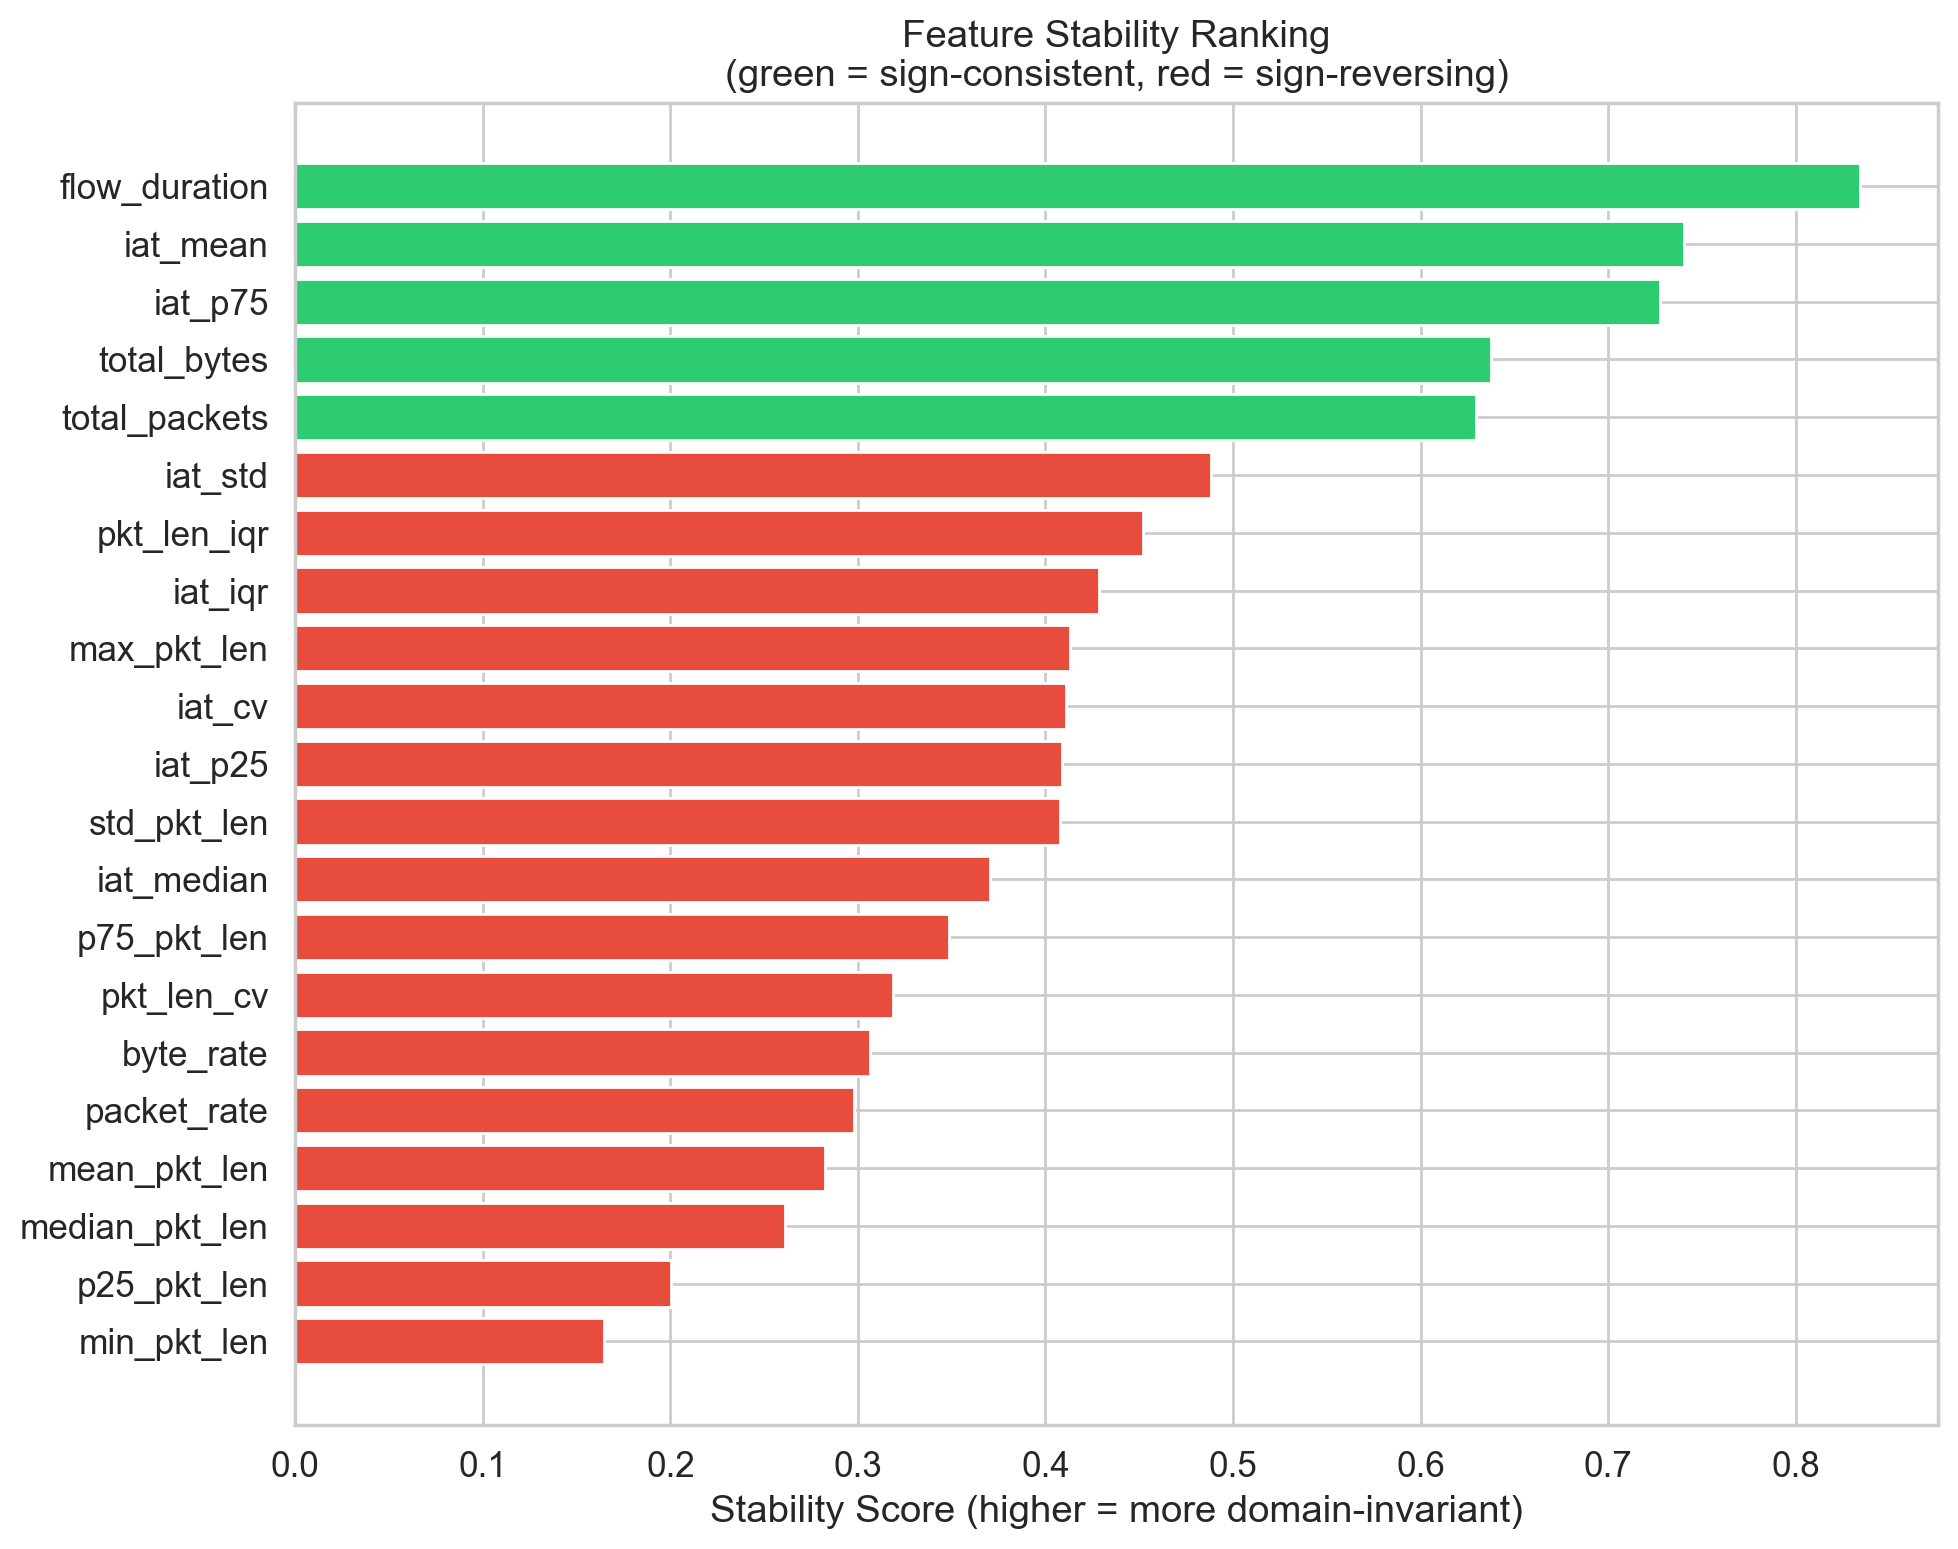


---
### 🖼 {_p.stem.replace("_", " ").title()}

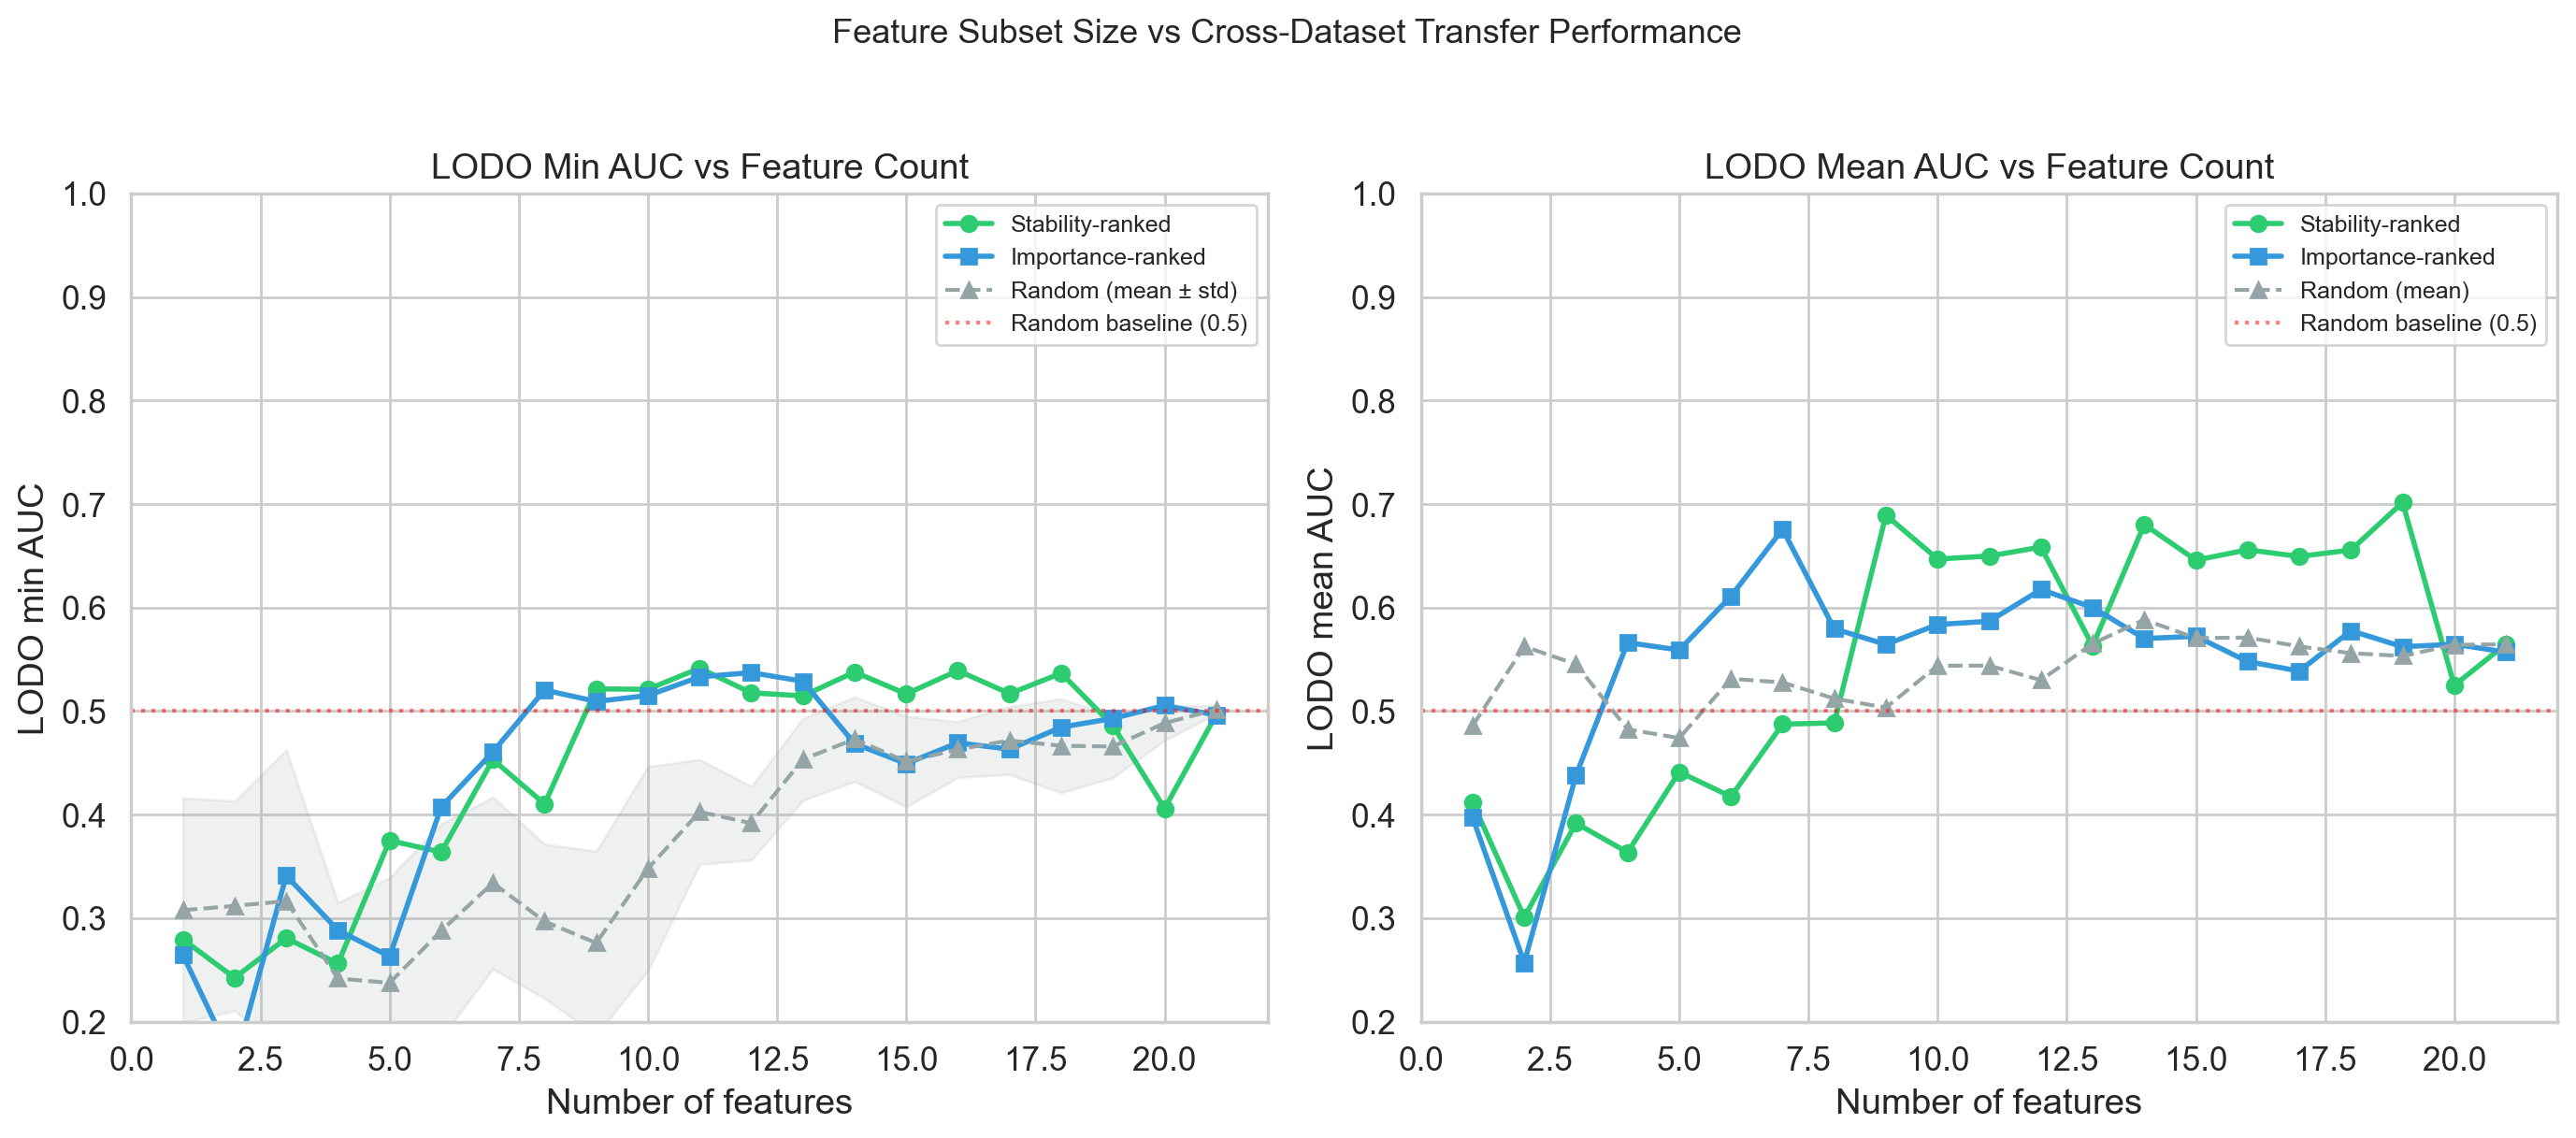


---
# 📋 Result Tables


### {_c.stem.replace("_", " ").title()}

,Unnamed: 0,suite,n_features,lodo_min_auc,lodo_mean_auc,pooled_auc,domain_auc
0,4,stability_top10,10,0.5210,0.6468,0.9695,0.9875
1,0,full_no_dir_21,21,0.4964,0.5498,0.9944,0.9971
2,3,stability_top7,7,0.4531,0.4873,0.9600,0.9767
3,7,zscore_norm_21,21,0.4285,0.4471,0.9961,1.0000
4,2,stability_top5,5,0.3749,0.4412,0.9484,0.9546
5,5,sign_consistent_only_5,5,0.3749,0.4412,0.9484,0.9546
6,1,stability_top3,3,0.2806,0.3917,0.9237,0.9095
7,6,no_strong_rev_13,13,0.2250,0.5587,0.9822,0.9883
8,8,zscore_sign_consistent_5,5,0.2163,0.4291,0.9619,0.9999


### {_c.stem.replace("_", " ").title()}

,Unnamed: 0,feature,sign_consistent,smd_variance,auc_variance,mean_jsd,domain_auc_single,mean_abs_smd,mean_vpn_auc,smd_variance_norm,auc_variance_norm,mean_jsd_norm,stability_score
0,0,flow_duration,1.0000,0.0234,0.0076,0.2942,0.8078,0.1396,0.4806,0.0026,0.0000,0.4781,0.8342
1,1,iat_mean,1.0000,0.0221,0.0869,0.2932,0.7833,0.1435,0.4176,0.0014,0.4900,0.4757,0.7402
2,2,iat_p75,1.0000,0.0207,0.0997,0.2738,0.7818,0.1546,0.4241,0.0001,0.5696,0.4273,0.7277
3,3,total_bytes,1.0000,0.5528,0.0800,0.2836,0.8490,0.4939,0.5070,0.5154,0.4472,0.4516,0.6376
4,4,total_packets,1.0000,0.5091,0.0790,0.4650,0.7841,0.7864,0.5241,0.4730,0.4414,0.9057,0.6298
5,5,iat_std,0.0000,0.0380,0.0421,0.2900,0.8156,0.1258,0.4168,0.0168,0.2134,0.4677,0.4881
6,6,pkt_len_iqr,0.0000,0.0883,0.0545,0.3755,0.8040,0.2320,0.4655,0.0655,0.2901,0.6817,0.4519
7,7,iat_iqr,0.0000,0.0312,0.0976,0.2719,0.7830,0.1386,0.4314,0.0101,0.5565,0.4225,0.4284
8,8,max_pkt_len,0.0000,0.1514,0.0541,0.4251,0.9370,0.2905,0.4325,0.1266,0.2871,0.8058,0.4130
9,9,iat_cv,0.0000,0.3002,0.0717,0.3487,0.6889,0.4044,0.4608,0.2708,0.3962,0.6146,0.4110


...

### {_c.stem.replace("_", " ").title()}

,Unnamed: 0,held_out,auc,recall,fpr,suite,n_features
0,0,iscx,0.5157,0.0003,0.0017,zscore_sign_consistent_5,5
1,1,usbvpn,0.2163,0.1833,0.6835,zscore_sign_consistent_5,5
2,2,vnat,0.5551,0.9278,0.5314,zscore_sign_consistent_5,5



---
### 🏁 {_j.stem.replace("_", " ").title()}

```json
{
  "notebook": "45_domain_invariant_feature_discovery",
  "date": "2026-04-04",
  "verdict": "NO DOMAIN-INVARIANT SUBSET EXISTS",
  "explanation": "No feature subset achieves LODO min AUC above 0.65. The best result (stability_top10: 0.5210) does not meaningfully improve over the baseline (0.4964). Compact header-only packet statistics cannot produce domain-invariant VPN detection across fundamentally different capture environments.",
  "recommendation": "Domain-invariant VPN detection requires either: (1) substantially richer features (payload, protocol metadata), (2) many more diverse training environments, or (3) domain-adversarial representation learning beyond simple feature selection.",
  "baseline": {
    "suite": "full_no_dir_21",
    "n_features": 21,
    "lodo_min_auc": 0.49639749149970397
  },
  "best_subset": {
    "suite": "stability_top10",
    "n_features": 10,
    "lodo_min_auc": 0.5209957047222278,
    "lodo_mean_auc": 0.646807076618335,
    "pooled_auc": 0.9695208948654901,
    "domain_auc": 0.9874718507362487
  },
  "sign_consistent_features": [
    "flow_duration",
    "iat_mean",
    "iat_p75",
    "total_bytes",
    "total_packets"
  ],
  "stability_ranking": [
    "flow_duration",
    "iat_mean",
    "iat_p75",
    "total_bytes",
    "total_packets",
    "iat_std",
    "pkt_len_iqr",
    "iat_iqr",
    "max_pkt_len",
    "iat_cv",
    "iat_p25",
    "std_pkt_len",
    "iat_median",
    "p75_pkt_len",
    "pkt_len_cv",
    "byte_rate",
    "packet_rate",
    "mean_pkt_len",
    "median_pkt_len",
    "p25_pkt_len",
    "min_pkt_len"
  ],
  "all_experiments": [
    {
      "suite": "stability_top10",
      "n_features": 10,
      "lodo_min_auc": 0.5209957047222278,
      "lodo_mean_auc": 0.646807076618335,
      "pooled_auc": 0.9695208948654901,
      "domain_auc": 0.9874718507362487
    },
    {
      "suite": "full_no_dir_21",
      "n_features": 21,
      "lodo_min_auc": 0.49639749149970397,
      "lodo_mean_auc": 0.54975919848699,
      "pooled_auc": 0.9943961785802622,
      "domain_auc": 0.9971484158807463
    },
    {
      "suite": "stability_top7",
      "n_features": 7,
      "lodo_min_auc": 0.4530579757148854,
      "lodo_mean_auc": 0.48730824356523467,
      "pooled_auc": 0.959975984272017,
      "domain_auc": 0.9767105212460004
    },
    {
      "suite": "zscore_norm_21",
      "n_features": 21,
      "lodo_min_auc": 0.42846256102398333,
      "lodo_mean_auc": 0.44709591345620764,
      "pooled_auc": 0.9961193820837759,
      "domain_auc": 1.0
    },
    {
      "suite": "stability_top5",
      "n_features": 5,
      "lodo_min_auc": 0.3748874762733211,
      "lodo_mean_auc": 0.44116210386479254,
      "pooled_auc": 0.9483685718598595,
      "domain_auc": 0.954615256078044
    },
    {
      "suite": "sign_consistent_only_5",
      "n_features": 5,
      "lodo_min_auc": 0.3748874762733211,
      "lodo_mean_auc": 0.44116210386479254,
      "pooled_auc": 0.9483685718598595,
      "domain_auc": 0.954615256078044
   
```


✅ NB45 gallery complete.


In [1]:
# ── Results Gallery: NB45 — Display all figures and tables ────────
import json, warnings
from pathlib import Path
from IPython.display import display, Image, Markdown
import pandas as pd

warnings.filterwarnings('ignore')

# Resolve output directory
if 'OUT' not in dir() and 'OUT_DIR' not in dir():
    ROOT = Path.cwd()
    if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
        ROOT = ROOT.parent
    _gallery_dir = ROOT / "artifacts" / "domain_invariant_feature_discovery"
else:
    _gallery_dir = Path(str(OUT)) if 'OUT' in dir() else Path(str(OUT_DIR))

# Also check for a figures/ subdirectory
_fig_dir = _gallery_dir / 'figures'

# Collect all PNGs
_pngs = sorted(_gallery_dir.glob('*.png'))
if _fig_dir.exists():
    _pngs += sorted(_fig_dir.glob('*.png'))
_pngs = sorted(set(_pngs), key=lambda p: p.name)

# Collect all CSVs
_csvs = sorted(_gallery_dir.glob('*.csv'))

display(Markdown(f'# \U0001f4ca NB45 Results Gallery — {len(_pngs)} figures, {len(_csvs)} tables'))

# ── Display all PNG figures ──
if _pngs:
    for _p in _pngs:
        display(Markdown(f'\n---\n### \U0001f5bc {{_p.stem.replace("_", " ").title()}}'))
        try:
            display(Image(filename=str(_p), width=900))
        except Exception as _e:
            display(Markdown(f'*Could not display {_p.name}: {_e}*'))
else:
    display(Markdown('*No PNG files found in gallery directory. Run notebook cells first.*'))

# ── Display all CSV tables ──
if _csvs:
    display(Markdown('\n---\n# \U0001f4cb Result Tables\n'))
    for _c in _csvs:
        try:
            _tbl = pd.read_csv(_c)
            display(Markdown(f'### {{_c.stem.replace("_", " ").title()}}'))
            for _col in _tbl.select_dtypes(include="float").columns:
                _tbl[_col] = _tbl[_col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
            display(_tbl)
        except Exception as _e:
            display(Markdown(f'*Could not load {_c.name}: {_e}*'))

# ── Display JSON verdict if present ──
_jsons = sorted(_gallery_dir.glob('*verdict*.json')) + sorted(_gallery_dir.glob('*summary*.json'))
_jsons = sorted(set(_jsons), key=lambda p: p.name)
for _j in _jsons[:2]:
    try:
        _data = json.loads(_j.read_text(encoding='utf-8'))
        display(Markdown(f'\n---\n### \U0001f3c1 {{_j.stem.replace("_", " ").title()}}'))
        display(Markdown(f'```json\n{json.dumps(_data, indent=2, default=str)[:3000]}\n```'))
    except Exception:
        pass

print('\n\u2705 NB45 gallery complete.')
